In [1]:
import pandas as pd 
import numpy as np
from tensorflow import keras
from keras.preprocessing import image
import keras.utils as image

In [2]:
test_img1=image.load_img(r'C:\Users\Lenovo\OneDrive\Desktop\practice\dataset\dataset\training_set\cats\cat.34' \
''
'.jpg')
test_img1

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\OneDrive\\Desktop\\practice\\dataset\\dataset\\training_set\\cats\\cat.34.jpg'

In [ ]:
import tensorflow
from tensorflow import keras
from keras.utils import to_categorical
from keras.models import Sequential,load_model
from keras.layers import Dense,Conv2D,MaxPool2D,Dropout,Flatten,Input
from keras.datasets import cifar10
import sys
import matplotlib.pyplot as plt


In [4]:
(x_train, y_train), (x_test, y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
x_train.shape

(50000, 32, 32, 3)

In [6]:
x_train[0].shape

(32, 32, 3)

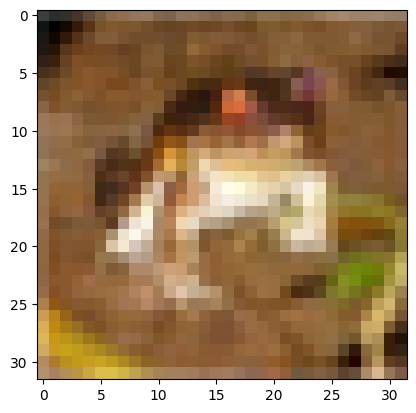

In [7]:
plt.imshow(x_train[0])


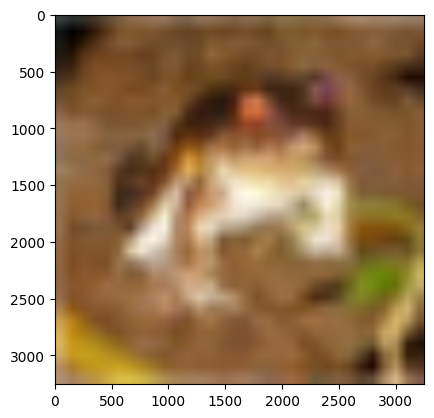

In [8]:
import cv2
resize=cv2.resize(x_train[0],(3255,3255))
plt.imshow(resize)



In [9]:
x_train.dtype

dtype('uint8')

In [10]:
x_train=x_train/255.0
x_test=x_test/255.0

In [11]:
x_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [12]:
model=Sequential()

In [13]:
to_categorical([0,1,2,3,4,5,6,7,8,9],num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [14]:
y_train_norm=to_categorical(y_train)
y_test_norm=to_categorical(y_test)

In [15]:
y_train_norm[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [16]:
y_train[0]

array([6], dtype=uint8)

In [17]:
cifar10.load_data??

Signature: cifar10.load_data()
Source:   
@keras_export("keras.datasets.cifar10.load_data")
def load_data():
    """Loads the CIFAR10 dataset.

    This is a dataset of 50,000 32x32 color training images and 10,000 test
    images, labeled over 10 categories. See more info at the
    [CIFAR homepage](https://www.cs.toronto.edu/~kriz/cifar.html).

    The classes are:

    | Label | Description |
    |:-----:|-------------|
    |   0   | airplane    |
    |   1   | automobile  |
    |   2   | bird        |
    |   3   | cat         |
    |   4   | deer        |
    |   5   | dog         |
    |   6   | frog        |
    |   7   | horse       |
    |   8   | ship        |
    |   9   | truck       |

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(50000, 32, 32, 3)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy 

In [28]:
model=Sequential()
model.add(Input(shape=x_train[0].shape))
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))


para
128 × 9 × 3 + 128 =
3584

hidden1   32768 × 128 + 128
 4194432

hidden2  64*128+62=8,256 

op    10*64+10=650

filters not depend on the image size but after it matter

In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,206,922 (16.05 MB)

 Trainable params: 4,206,922 (16.05 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
x_train[0].shape

(32, 32, 3)

In [31]:
MaxPool2D??

Init signature: MaxPool2D(self, *args, **kwargs)
Source:        
@keras_export(["keras.layers.MaxPooling2D", "keras.layers.MaxPool2D"])
class MaxPooling2D(BasePooling):
    """Max pooling operation for 2D spatial data.

    Downsamples the input along its spatial dimensions (height and width)
    by taking the maximum value over an input window
    (of size defined by `pool_size`) for each channel of the input.
    The window is shifted by `strides` along each dimension.

    The resulting output when using the `"valid"` padding option has a spatial
    shape (number of rows or columns) of:
    `output_shape = math.floor((input_shape - pool_size) / strides) + 1`
    (when `input_shape >= pool_size`)

    The resulting output shape when using the `"same"` padding option is:
    `output_shape = math.floor((input_shape - 1) / strides) + 1`

    Args:
        pool_size: int or tuple of 2 integers, factors by which to downscale
            (dim1, dim2). If only one integer is specified, the

In [32]:
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train_norm,epochs=50,batch_size=64,validation_data=(x_test,y_test_norm))

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2781 - loss: 2.0079 - val_accuracy: 0.3401 - val_loss: 1.8375
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3841 - loss: 1.7306 - val_accuracy: 0.3917 - val_loss: 1.6985
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4419 - loss: 1.5603 - val_accuracy: 0.4586 - val_loss: 1.4831
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4888 - loss: 1.4363 - val_accuracy: 0.4978 - val_loss: 1.3886
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5191 - loss: 1.3458 - val_accuracy: 0.4404 - val_loss: 1.6362
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5478 - loss: 1.2775 - val_accuracy: 0.4963 - val_loss: 1.4410
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5729 - loss: 1.2172 - val_accuracy: 0.5078 - val_loss: 1.3405
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5892 - loss: 1.1662 - val_accuracy: 0.

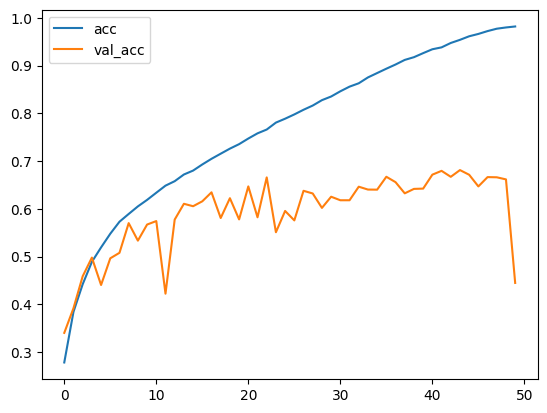

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.legend()


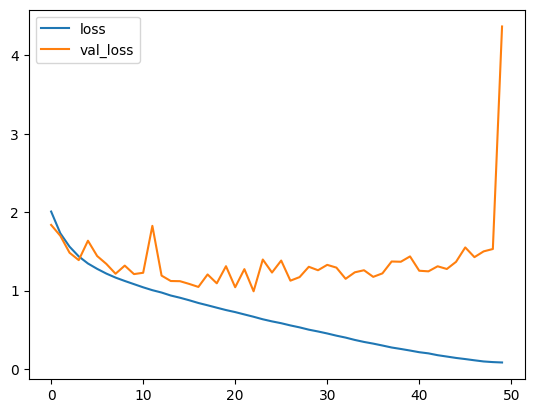

In [ ]:
plt.plot(history.history['accuracy'],label='acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.legend()
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')

plt.legend()


In [37]:
model.evaluate(x_test,y_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4447 - loss: 4.3664


[4.366384983062744, 0.4447000026702881]

In [38]:
model.save('cifer10.keras')

In [39]:
img=x_test[0].reshape((1,32,32,3))

In [40]:
img.shape

(1, 32, 32, 3)

In [41]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


array([[7.9469273e-06, 5.9190552e-05, 5.1728566e-04, 6.1797470e-01,
        5.2386691e-05, 4.0336265e-04, 3.8088149e-01, 2.0349050e-08,
        1.0306008e-04, 5.6846994e-07]], dtype=float32)

In [44]:
y_test[0]

array([3], dtype=uint8)

In [43]:
import numpy as np
np.argmax(model.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


np.int64(3)

In [45]:
import os 


In [46]:
os.getcwd()

'/content'

In [ ]:
model.save(r'C:\Users\Lenovo\OneDrive\Desktop\practice\lecture\DL\cifer10.keras')

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2365891533.py, line 1)

In [51]:
model1=load_model(r'C:\Users\Lenovo\OneDrive\Desktop\practice\lecture\DL\cifer10.keras')

In [54]:
np.argmax(model1.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


np.int64(3)

In [58]:
model2 = Sequential()
model2.add(Input(shape=x_train[0].shape))

model2.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(MaxPool2D(pool_size=(2, 2)))
model2.add(Dropout(0.2))

model2.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(MaxPool2D(pool_size=(2, 2)))
model2.add(Dropout(0.2))

model2.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model2.add(MaxPool2D(pool_size=(2, 2)))
model2.add(Dropout(0.2))


model2.add(Flatten())

model2.add(Dense(128,activation="relu"))
model2.add(Dropout(0.2))
model2.add(Dense(10,activation="softmax"))

In [59]:
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model2.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])
history=model2.fit(x_train,y_train_norm,epochs=50,batch_size=64,validation_data=(x_test,y_test_norm))

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.2480 - loss: 2.0285 - val_accuracy: 0.2884 - val_loss: 1.9797
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3721 - loss: 1.7126 - val_accuracy: 0.3981 - val_loss: 1.6261
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4218 - loss: 1.5766 - val_accuracy: 0.4747 - val_loss: 1.4464
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4609 - loss: 1.4745 - val_accuracy: 0.4409 - val_loss: 1.5275
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4943 - loss: 1.3952 - val_accuracy: 0.4476 - val_loss: 1.5238
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5171 - loss: 1.3276 - val_accuracy: 0.5478 - val_loss: 1.2545
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5450 - loss: 1.2659 - val_accuracy: 0.4577 - val_loss: 1.5305
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5672 - loss: 1.2089 - val_accuracy:

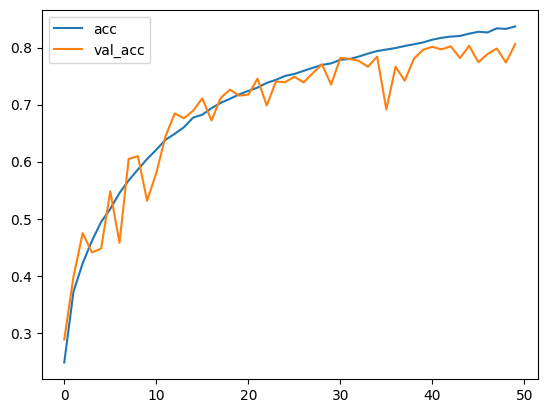

In [61]:
plt.plot(history.history['accuracy'],label='acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.legend()


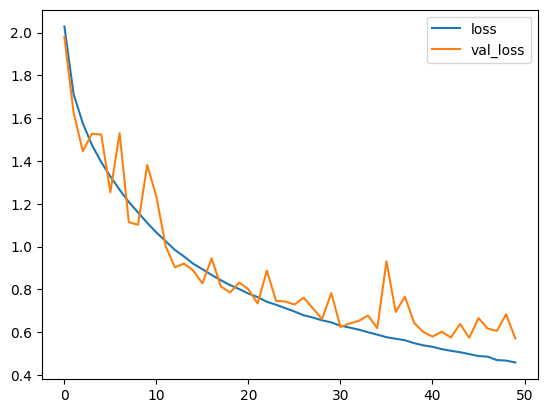

In [62]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')

plt.legend()

In [63]:
model2.save('cifer101.keras')

In [64]:
from google.colab import files
files.download("cifer101.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>